In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

## 1. 데이터 준비

In [6]:
# 60, 62, 65, 67, 68, 70, 72, 75, 78, 95
scores = [60, 62, 65, 67, 68, 70, 72, 75, 78, 95]

scores_np = np.array(scores)
scores_series = pd.Series(scores)

print(scores_np)
print(scores_series)

[60 62 65 67 68 70 72 75 78 95]
0    60
1    62
2    65
3    67
4    68
5    70
6    72
7    75
8    78
9    95
dtype: int64


## 2. IQR 방법

In [20]:
# 중앙값
median = scores_series.median()

# Q1, Q3
Q1 = scores_series.quantile(0.25)
Q3 = scores_series.quantile(0.75)

# IQR
IQR = Q3 - Q1

# 이상치 기준
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 최소값, 최대값
minimum = scores_series.min()
maximum = scores_series.max()

print("중앙값:", median)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("하한:", lower)
print("상한:", upper)
print("최소값:", minimum)
print("최대값:", maximum)

# 이상치
outliers_iqr = scores_series[
    (scores_series < lower) | (scores_series > upper)
]

print("IQR 이상치:", outliers_iqr.values)


중앙값: 69.0
Q1: 65.5
Q3: 74.25
IQR: 8.75
하한: 52.375
상한: 87.375
최소값: 60
최대값: 95
IQR 이상치: [95]


## 3. 박스플롯

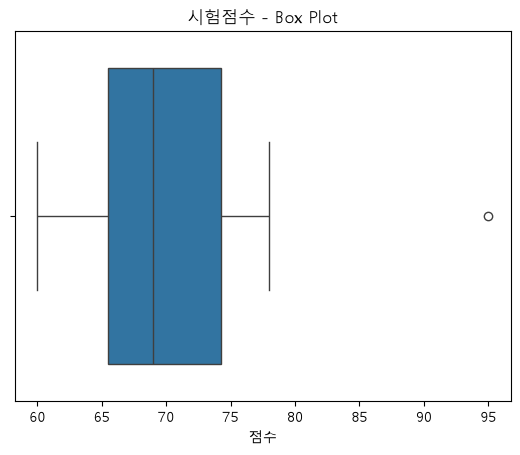

In [16]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig = plt.figure()

axes1 = fig.add_subplot(1,1,1)

sns.boxplot(x=scores_series, ax=axes1)

axes1.set_title("시험점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()

## 4. Z-score 방법

In [17]:
# 평균
mean = scores_np.mean()

# 분산
variance = scores_np.var()

# 표준편차
std = scores_np.std()

print("평균:", round(mean, 2))
print("분산:", round(variance, 2))
print("표준편차:", round(std, 2))


# Z-score 계산
z_scores = (scores_np - mean) / std

print("Z-score:")
print(np.round(z_scores, 2))

평균: 71.2
분산: 90.56
표준편차: 9.52
Z-score:
[-1.18 -0.97 -0.65 -0.44 -0.34 -0.13  0.08  0.4   0.71  2.5 ]


## 5. Z-score 이상치 판단

In [18]:
outliers_z = scores_np[np.abs(z_scores) > 3]

print("Z-score 이상치:")
print(outliers_z)

Z-score 이상치:
[]


## 6. 히스토그램

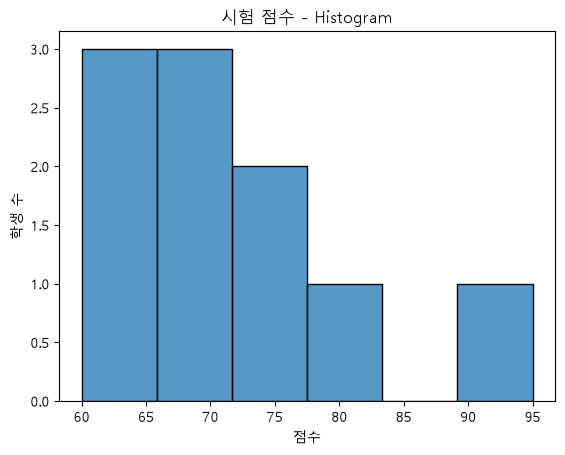

In [21]:
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_series, bins=6, ax=axes1)

axes1.set_title("시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()